In [1]:
%matplotlib widget

from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

cube = SpectralCube('/Volumes/RayPass/Research/SIGNALS/N604_SN4/3266414z.hdf5')

unknown|INFO| Cube is level 3
unknown|WARNING| error reading param from attributes polyref: Insufficient precision in available types to represent (79, 64, 15, 0, 64)
unknown|WARNING| error reading param from attributes polyref: Insufficient precision in available types to represent (79, 64, 15, 0, 64)
unknown|INFO| shape: (2048, 2064, 934)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


In [2]:
estimates = cube.estimate_parameters_in_region('/Volumes/RayPass/Research/SIGNALS/N604_SN4/N604_Box.reg', 
                                               ('Halpha','[NII]6548','[NII]6583','Halpha','[NII]6548','[NII]6583'), 
                                               [-300,300],
                                               binning=3,
                                               max_comps=2)

unknown|INFO| Init of the parallel processing server with 12 threads
unknown|INFO| passed mapped kwargs : []
unknown|INFO| 195 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [==========] [100%] [completed in 2m16s]                                     

unknown|INFO| Closing parallel processing server


unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_velocity.0.fits in 0.59 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_score.0.fits in 0.60 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_Halpha.0.fits in 0.70 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_NII6548.0.fits in 0.63 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_NII6583.0.fits in 0.68 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_Halpha.0.fits in 0.51 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_NII6548.0.fits in 0.66 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_NII6583.0.fits in 0.50 s 
unknown|INFO| Data written as ./NGC604_SN4/Estimated_3x3/NGC604_SN4

(720.0, 1320.0)

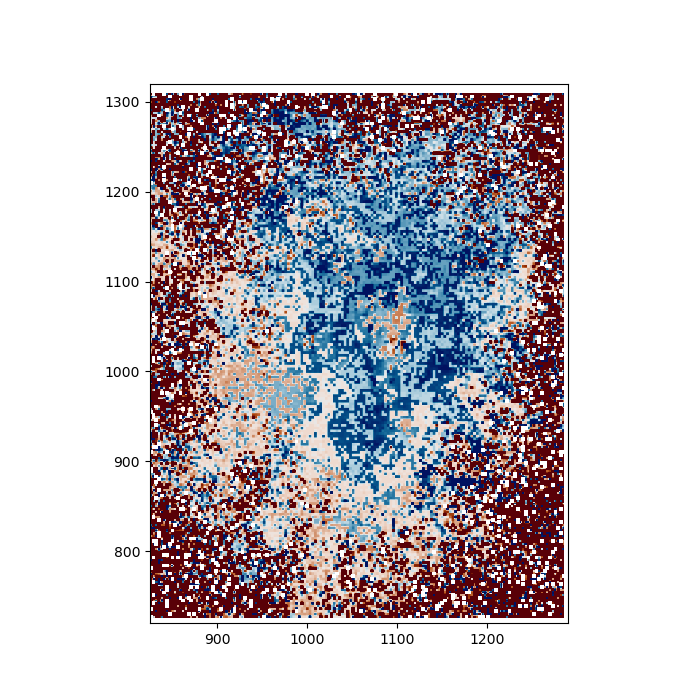

In [3]:
import orb.utils.graph as graph
from cmcrameri import cm

vel_map = orb.utils.io.read_fits('./NGC604_SN4/Estimated_3x3/NGC604_SN4.SpectralCube.estimated_velocity.1.fits')
graph.imshow(vel_map, vmin=-260, vmax=-160, cmap=cm.vik)
plt.xlim(825,1290)
plt.ylim(720,1320)

In [ ]:
cube.fit_lines_in_region('/Volumes/RayPass/Research/SIGNALS/N604_SN4/N604_Box.reg',
                         ['Halpha','[NII]6583','[NII]6548','Halpha','[NII]6583','[NII]6548'],
                         fmodel='sincgaussphased',
                         alpha_def=['1','1','1','1','1','1'],
                         alpha_cov=[np.pi/20],
                         pos_def=['1','1','1','2','2','2'],
                         pos_cov=[-270,-180],
                         sigma_def=['1','1','1','2','2','2'],
                         sigma_cov=[10,10],
#                       poly_order=2,
                         nofilter='False', binning=1)

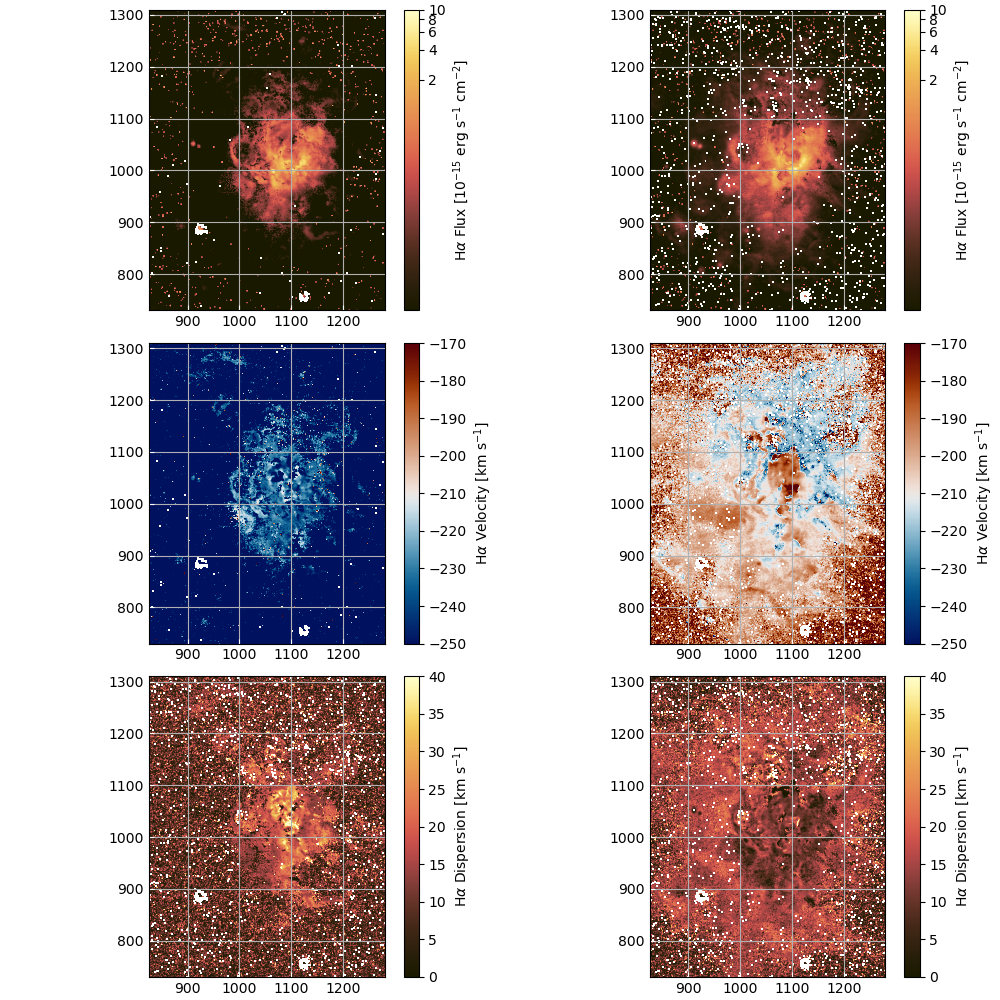

In [8]:
from cmcrameri import cm
from astropy.visualization import ImageNormalize, ManualInterval, LogStretch

fig = plt.figure(figsize=(10,10), constrained_layout=True)
ax = fig.subplot_mosaic(
    """
    ab
    cd
    ef
    """)

halpha1 = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563.1x1.flux.fits')
norm = ImageNormalize(halpha1.T/1e-15, interval=ManualInterval(vmin=1e-17/1e-15, vmax=1e-14/1e-15), stretch=LogStretch())
t = ax['a'].imshow(halpha1.T/1e-15, origin='lower', norm=norm, cmap=cm.lajolla)
cbar = plt.colorbar(t, ax=ax['a'])
cbar.set_label(r'H$\alpha$ Flux [$10^{-15}$ erg s$^{-1}$ cm$^{-2}$]')

halpha2 = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563_2.1x1.flux.fits')
norm = ImageNormalize(halpha2.T/1e-15, interval=ManualInterval(vmin=1e-17/1e-15, vmax=1e-14/1e-15), stretch=LogStretch())
t = ax['b'].imshow(halpha2.T/1e-15, origin='lower', norm=norm, cmap=cm.lajolla)
cbar = plt.colorbar(t, ax=ax['b'])
cbar.set_label(r'H$\alpha$ Flux [$10^{-15}$ erg s$^{-1}$ cm$^{-2}$]')

# _map1 = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6583.1x1.flux.fits')
# _map2 = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563.1x1.flux.fits')
# _map = np.log10(_map1/_map2)
# # norm = ImageNormalize(_map.T/1e-15, interval=ManualInterval(vmin=1e-17/1e-15, vmax=1e-14/1e-15), stretch=LogStretch())
# t = ax['b'].imshow(_map.T, origin='lower', vmin=-1.3, vmax=-0.3, cmap=cm.lajolla)
# cbar = plt.colorbar(t, ax=ax['b'])
# cbar.set_label(r'[N II] Flux [$10^{-15}$ erg s$^{-1}$ cm$^{-2}$]')

_map = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563.1x1.velocity.fits')
# norm = ImageNormalize(_map.T, interval=ManualInterval(vmin=1e-17, vmax=1e-14), stretch=LogStretch())
t = ax['c'].imshow(_map.T, origin='lower', vmin=-250, vmax=-170, cmap=cm.vik)
cbar = plt.colorbar(t, ax=ax['c'])
cbar.set_label(r'H$\alpha$ Velocity [km s$^{-1}$]')
# ax['c'].contour(halpha1.T, levels=np.logspace(-16.7,-14,6), colors='k', linestyles='solid', linewidths=1)

_map = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563_2.1x1.velocity.fits')
# norm = ImageNormalize(_map.T, interval=ManualInterval(vmin=1e-17, vmax=1e-14), stretch=LogStretch())
t = ax['d'].imshow(_map.T, origin='lower', vmin=-250, vmax=-170, cmap=cm.vik)
cbar = plt.colorbar(t, ax=ax['d'])
cbar.set_label(r'H$\alpha$ Velocity [km s$^{-1}$]')
# ax['d'].contour(halpha2.T, levels=np.logspace(-16.7,-14,6), colors='k', linestyles='solid', linewidths=1)

_map = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563.1x1.sigma.fits')
# norm = ImageNormalize(_map.T, interval=ManualInterval(vmin=1e-17, vmax=1e-14), stretch=LogStretch())
t = ax['e'].imshow(_map.T, origin='lower', vmin=0, vmax=40, cmap=cm.lajolla)
cbar = plt.colorbar(t, ax=ax['e'])
cbar.set_label(r'H$\alpha$ Dispersion [km s$^{-1}$]')
# ax['e'].contour(halpha1.T, levels=np.logspace(-16.7,-14,6), colors='k', linestyles='solid', linewidths=1)

_map = orb.utils.io.read_fits('./NGC604_SN4/MAPS/NGC604_SN4.LineMaps.map.6563_2.1x1.sigma.fits')
# norm = ImageNormalize(_map.T, interval=ManualInterval(vmin=1e-17, vmax=1e-14), stretch=LogStretch())
t = ax['f'].imshow(_map.T, origin='lower', vmin=0, vmax=40, cmap=cm.lajolla)
cbar = plt.colorbar(t, ax=ax['f'])
cbar.set_label(r'H$\alpha$ Dispersion [km s$^{-1}$]')
# ax['f'].contour(halpha2.T, levels=np.logspace(-16.7,-14,6), colors='k', linestyles='solid', linewidths=1)


for a in ['a','b','c','d','e','f']:
    ax[a].set_xlim(825,1280)
    ax[a].set_ylim(730,1310)

    ax[a].tick_params(direction='in', color='white')
    ax[a].grid()

    # if a in ['a','b']:
    #     ax[a].get_xaxis().set_ticklabels([])
    # if a in ['b','d']:
    #     ax[a].get_yaxis().set_ticklabels([])